## 01 - Exploration und Aufbereitung des TOI-Datensatzes

In diesem Notebook wird der TESS Object of INteresst (TOI) Katalog des NASA Exoplanet Archive untersucht und für die weitere Verarbeitung vorbereitet

#### Bibliotheken

In [2]:
# Basisbibliotheken
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
import requests
from io import StringIO

# Visualisierung
import matplotlib.pyplot as plt

#### Projektpfade

In [3]:
cwd = Path.cwd()

if cwd.name.lower() == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "catalogs"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root directory:", PROJECT_ROOT)
print("Raw data directory:", RAW_DIR)
print("Interim data directory:", INTERIM_DIR)
print("Processed data directory:", PROCESSED_DIR)

Project root directory: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets
Raw data directory: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\raw\catalogs
Interim data directory: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim
Processed data directory: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\processed


#### NASA-TAP-Abfrage

In [15]:
TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = """
SELECT *
FROM toi
"""

params = {
    "query": query,
    "format": "csv",
}

#### Snapshot laden

Hier wurde über das gesamte Projekt mit dem, am 16.08.2026 heruntegeladenen, Datensatz gearbeitet. Fall dieser nicht vorhandne ist, wird der Datensatz neu heruntergeladen.

In [71]:
snapshot_date = "2026-08-16"

raw_file = RAW_DIR / f"toi_{snapshot_date}.csv"

if raw_file.exists():
    print(f"Snapshot wird geladen:")
    print(raw_file)

    toi_raw = pd.read_csv(raw_file)

else:
    print("TOI-Datensatz wird heruntergeladen...")

    response = requests.get(
        TAP_URL, params=params, timeout=60
    )

    response.raise_for_status()

    raw_file.write_text(
        response.text, encoding="utf-8"
    )

    toi_raw = pd.read_csv(
        StringIO(response.text)
    )

    print("Gespeichert unter:")
    print(raw_file)

Snapshot wird geladen:
c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\raw\catalogs\toi_2026-08-16.csv


#### Metadaten des Snaphots speichern

In [73]:
metadata_file = RAW_DIR / f"toi_{snapshot_date}_metadata.txt"

metadata = f"""
Source: NASA Exoplanet Archive
Table: toi
Endpoint: {TAP_URL}
Dataset snapshot date: {snapshot_date}
"""
metadata_file.write_text(metadata.strip(), encoding="utf-8")


print(metadata)


Source: NASA Exoplanet Archive
Table: toi
Endpoint: https://exoplanetarchive.ipac.caltech.edu/TAP/sync
Dataset snapshot date: 2026-08-16



#### Ausgabe von Größe und head() des Rohdatensatzes

In [18]:
print("Zeilen:", toi_raw.shape[0])
print("Spalten:", toi_raw.shape[1])

toi_raw.head()

Zeilen: 8113
Spalten: 16


,toi,tid,tfopwg_disp,pl_orbper,pl_tranmid,pl_trandurh,pl_trandep,pl_rade,st_tmag,st_teff,st_logg,st_rad,ra,dec,toi_created,rowupdate
0,1063.01,406976746,PC,10.066524,2.458629e+06,2.402319,839.904487,2.727282,9.0689,5552.0,4.61783,0.791742,230.555493,-83.056214,2019-08-16 20:20:49,2025-07-09 16:00:02
1,1064.01,79748331,CP,6.443866,2.458657e+06,1.930945,1121.951227,2.460344,10.0059,4803.0,4.52079,0.737189,296.003935,-47.562030,2019-08-16 20:20:42,2024-04-25 10:08:01
2,1064.02,79748331,CP,12.226560,2.458664e+06,2.190438,1206.369329,2.601477,10.0059,4803.0,4.52079,0.737189,296.003935,-47.562030,2019-08-16 20:20:42,2024-04-25 10:08:01
3,1065.01,7088246,KP,2.160515,2.458654e+06,1.480696,13774.879462,12.549193,13.2851,5780.0,4.32928,1.200000,286.366750,-50.067350,2019-08-16 20:20:41,2026-04-15 10:08:02
4,1066.01,201604954,KP,4.606184,2.458658e+06,3.121643,13793.034867,12.962219,11.9707,5670.0,4.39250,1.070000,285.096517,-54.893341,2019-08-16 20:20:44,2021-10-29 12:59:15


#### Benötigte Spalten prüfen

In [21]:
columns = [
    "toi",
    "tid",
    "tfopwg_disp",
    "pl_orbper",
    "pl_tranmid",
    "pl_trandurh",
    "pl_trandep",
    "st_tmag",
    "st_teff",
    "st_rad",
    "ra",
    "dec",
    "toi_created",
    "rowupdate"
]

missing_columns = [
    col for col in columns
    if col not in toi_raw.columns
]

print("Fehlende erwartete Spalten:", missing_columns)

toi = toi_raw[columns].copy()

toi.head()

Fehlende erwartete Spalten: []


,toi,tid,tfopwg_disp,pl_orbper,pl_tranmid,pl_trandurh,pl_trandep,st_tmag,st_teff,st_rad,ra,dec,toi_created,rowupdate
0,1063.01,406976746,PC,10.066524,2.458629e+06,2.402319,839.904487,9.0689,5552.0,0.791742,230.555493,-83.056214,2019-08-16 20:20:49,2025-07-09 16:00:02
1,1064.01,79748331,CP,6.443866,2.458657e+06,1.930945,1121.951227,10.0059,4803.0,0.737189,296.003935,-47.562030,2019-08-16 20:20:42,2024-04-25 10:08:01
2,1064.02,79748331,CP,12.226560,2.458664e+06,2.190438,1206.369329,10.0059,4803.0,0.737189,296.003935,-47.562030,2019-08-16 20:20:42,2024-04-25 10:08:01
3,1065.01,7088246,KP,2.160515,2.458654e+06,1.480696,13774.879462,13.2851,5780.0,1.200000,286.366750,-50.067350,2019-08-16 20:20:41,2026-04-15 10:08:02
4,1066.01,201604954,KP,4.606184,2.458658e+06,3.121643,13793.034867,11.9707,5670.0,1.070000,285.096517,-54.893341,2019-08-16 20:20:44,2021-10-29 12:59:15


#### Spalte "tfopwg_disp" bereinigen

In [22]:
toi["tfopwg_disp"] = (
    toi["tfopwg_disp"]
    .astype("string")
    .str.strip()
    .str.upper()
)

#### Verteilung der Klassen

In [23]:
disposition_counts = (toi["tfopwg_disp"].value_counts(dropna=False))

disposition_counts

tfopwg_disp
PC      4927
FP      1255
CP       744
KP       597
APC      487
FA       100
<NA>       3
Name: count, dtype: Int64

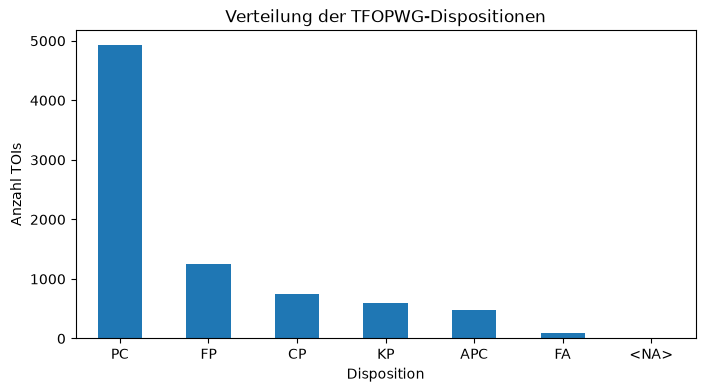

In [24]:
disposition_counts.dropna().plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Verteilung der TFOPWG-Dispositionen")
plt.xlabel("Disposition")
plt.ylabel("Anzahl TOIs")
plt.xticks(rotation=0)
plt.show()

#### Binäre Labels setzen

In [26]:
label_map = {
    "CP": 1,   # Confirmed Planet
    "KP": 1,   # Known Planet
    "FP": 0,   # False Positive
    "FA": 0    # False Alarm
}

toi["label"] = (
    toi["tfopwg_disp"]
    .map(label_map)
    .astype("Int64")
)

toi[["tfopwg_disp", "label"]].head(12)

,tfopwg_disp,label
0,PC,<NA>
1,CP,1
2,CP,1
3,KP,1
4,KP,1
5,KP,1
6,KP,1
7,KP,1
8,KP,1
9,FP,0


#### Sicher gelabelte Klassen

In [36]:
labeled = toi[toi["label"].notna()].copy()

print(labeled["label"].value_counts())
print()
print(labeled["label"].value_counts(normalize=True))

label
0    1355
1    1341
Name: count, dtype: Int64

label
0    0.502596
1    0.497404
Name: proportion, dtype: Float64


### Analyse von fehlenden Daten

Für die spätere Verarbeitung der TESS-Lichtkurven werden hier insbesondere
die Transitparameter untersucht.

Für das Phase Folding werden die Spalten "`pl_orbper`: Orbitalperiode" und "`pl_tranmid`: Transitmittelpunkt" benötigt.

Für die Local View wird "`pl_trandurh`: Transitdauer" benötigt.

Fehlende Parameter führen zunächst nicht dazu, dass ein TOI ausgeschlossen wird.

In [39]:
missing_values = pd.DataFrame({
    "missing_count": toi.drop(columns="label").isna().sum(),
    "missing_percent": toi.drop(columns="label").isna().mean() * 100
})

missing_values = missing_values.sort_values(
    "missing_percent",
    ascending=False
)

missing_values

,missing_count,missing_percent
st_rad,627,7.728337
st_teff,174,2.144706
pl_orbper,110,1.355849
pl_trandurh,4,0.049304
tfopwg_disp,3,0.036978
toi,0,0.000000
pl_tranmid,0,0.000000
tid,0,0.000000
st_tmag,0,0.000000
pl_trandep,0,0.000000


#### Fehlende Daten

In [40]:
TRANSIT_COLUMNS = [
    "pl_orbper",
    "pl_tranmid",
    "pl_trandurh"
]

missing_transit = (
    labeled[TRANSIT_COLUMNS]
    .isna()
    .sum()
)

print("Fehlende Transitparameter:")
print(missing_transit)

Fehlende Transitparameter:
pl_orbper      33
pl_tranmid      0
pl_trandurh     0
dtype: int64


In [41]:
has_complete_transit = (
    labeled[TRANSIT_COLUMNS]
    .notna()
    .all(axis=1)
)

print("Sicher gelabelte TOIs insgesamt:", len(labeled))
print(
    "Mit vollständigen Transitparametern:",
    has_complete_transit.sum()
)

print(
    "Anteil vollständig:",
    f"{has_complete_transit.mean() * 100:.1f}%"
)

Sicher gelabelte TOIs insgesamt: 2696
Mit vollständigen Transitparametern: 2663
Anteil vollständig: 98.8%


#### Vollständig verwendbare Paramter

In [42]:
supervised = labeled[
    has_complete_transit
].copy()

print("Verwendbare TOIs:", len(supervised))

Verwendbare TOIs: 2663


#### Gelabelte Kandidaten

In [43]:
print("Klassen nach Transitparameter-Filter:")
print(supervised["label"].value_counts())

print()

print("Anteile:")
print(
    supervised["label"]
    .value_counts(normalize=True)
)

Klassen nach Transitparameter-Filter:
label
0    1339
1    1324
Name: count, dtype: Int64

Anteile:
label
0    0.502816
1    0.497184
Name: proportion, dtype: Float64


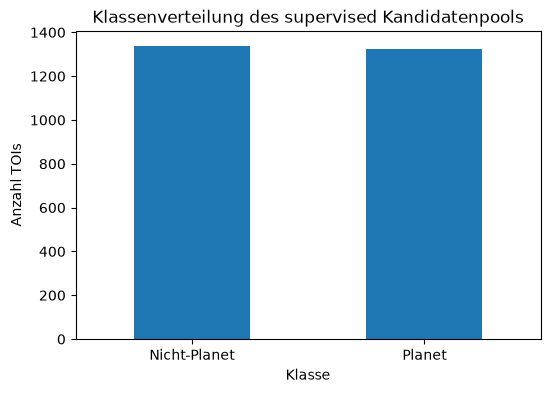

In [45]:
class_counts = ( supervised["label"].value_counts().sort_index())

class_counts.index = ["Nicht-Planet", "Planet"]

class_counts.plot(kind="bar", figsize=(6, 4))

plt.title("Klassenverteilung des supervised Kandidatenpools")
plt.xlabel("Klasse")
plt.ylabel("Anzahl TOIs")
plt.xticks(rotation=0)
plt.show()

#### TOIs pro TIC-ID untersuchen

Ein TIC (Stern) kann mehrere TOIs besitzen

In [46]:
print("Anzahl TOIs:", len(supervised))
print("Eindeutige TIC IDs:", supervised["tid"].nunique())

tois_per_star = (supervised.groupby("tid").size())

print("Sterne mit mehr als einem TOI:", (tois_per_star > 1).sum())

print("Maximale Anzahl TOIs bei einem Stern:", tois_per_star.max())

Anzahl TOIs: 2663
Eindeutige TIC IDs: 2524
Sterne mit mehr als einem TOI: 103
Maximale Anzahl TOIs bei einem Stern: 5


In [54]:
labels_per_star = (supervised.groupby("tid")["label"].nunique())

mixed_label_tics = labels_per_star[labels_per_star > 1]

print("TIC IDs mit Planet- und Nicht-Planet-Kandidaten:", len(mixed_label_tics))

TIC IDs mit Planet- und Nicht-Planet-Kandidaten: 5


#### PC/ACP (ungelabelt) untersuchen

In [57]:
unlabeled = toi[toi["label"].isna()].copy()

print("Nicht für supervised Training gelabelt:", len(unlabeled))

print()
print(unlabeled["tfopwg_disp"].value_counts(dropna=False))

Nicht für supervised Training gelabelt: 5417

tfopwg_disp
PC      4927
APC      487
<NA>       3
Name: count, dtype: Int64


In [60]:
unlabeled_complete = (
    unlabeled[TRANSIT_COLUMNS]
    .notna()
    .all(axis=1)
)

print("Unlabelled TOIs insgesamt:", len(unlabeled))

print("Mit vollständigen Transitparametern:", unlabeled_complete.sum())

print("Anteil vollständig:", f"{unlabeled_complete.mean() * 100:.1f}%")

Unlabelled TOIs insgesamt: 5417
Mit vollständigen Transitparametern: 5336
Anteil vollständig: 98.5%


#### Zusammenfassung vom Datensatz

In [61]:
dataset_summary = pd.DataFrame({
    "Kategorie": [
        "TOIs insgesamt",
        "Eindeutige TIC IDs",
        "Sicher gelabelte TOIs",
        "Supervised + vollständige Transitparameter",
        "Planet",
        "Nicht-Planet",
        "Nicht sicher gelabelt"
    ],
    "Anzahl": [
        len(toi),
        toi["tid"].nunique(),
        len(labeled),
        len(supervised),
        (supervised["label"] == 1).sum(),
        (supervised["label"] == 0).sum(),
        len(unlabeled)
    ]
})

dataset_summary

,Kategorie,Anzahl
0,TOIs insgesamt,8113
1,Eindeutige TIC IDs,7799
2,Sicher gelabelte TOIs,2696
3,Supervised + vollständige Transitparameter,2663
4,Planet,1324
5,Nicht-Planet,1339
6,Nicht sicher gelabelt,5417


#### Vollständigen Datensatz speichern

In [62]:
catalog_file = (
    INTERIM_DIR /
    f"toi_catalog_{snapshot_date}.csv"
)

toi.to_csv(
    catalog_file,
    index=False
)

print("Gespeichert:", catalog_file)

Gespeichert: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\toi_catalog_2026-08-16.csv


#### Supervised Kandidaten speichern

In [63]:
supervised_file = (
    INTERIM_DIR /
    f"toi_supervised_candidates_{snapshot_date}.csv"
)

supervised.to_csv(
    supervised_file,
    index=False
)

print("Gespeichert:", supervised_file)

Gespeichert: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\toi_supervised_candidates_2026-08-16.csv
